In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

import util

%config InlineBackend.figure_format = "svg"

torch.manual_seed(42)

# Training a Neural Network with PyTorch

In a previous lecture on feature maps, we saw a data set similar to the one below. This data exhibits a non-linear pattern, and a simple linear classifier won't work well unless we use a non-linear feature map to transform it before training.

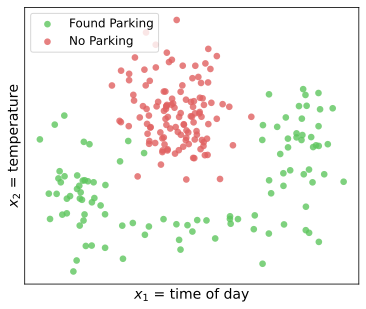

In [3]:
data = np.loadtxt("parking.csv", delimiter=",", skiprows=1)
time, temp, label = data[:, 0], data[:, 1], data[:, 2]

util.plot_parking(time, temp, label=label == 1);

## Step 0) Prepare the data

We standardize the features so that gradient descent converges more easily, then convert everything to PyTorch tensors.

In [4]:
X = np.column_stack([time, temp])
y = label

# standardize features to zero mean, unit variance
mu, sigma = X.mean(axis=0), X.std(axis=0)
X_std = (X - mu) / sigma

# convert to float32 tensors
X_train = torch.tensor(X_std, dtype=torch.float32)
# unsqueeze adds a dimension to y_train; it converts a 1-dimensional array with n entries
# into a 2-dimensional array with shape (n, 1), which is what PyTorch expects.
y_train = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

## Step 1) Define the model

We'll use a small network with three hidden layers. The input layer must have two nodes, since our input is two dimensional; the output layer must have one node, since we're predicting a single label. We will use 32 nodes in the first hidden layer, 32 in the second, and 2 in the last -- there isn't any single "best" architecture, however, and you can try playing around with these numbers to see how they affect the results. The hidden layers will use the ReLU, and we'll use a sigmoid activation on the output node.

There are several ways to define such a neural network in PyTorch. Starting with the most general and explicit:

In [5]:
class ClassificationModel(nn.Module):

    def __init__(self):
        super().__init__()

        # define the three hidden layers and the output layer;
        # we'll make a fully-connected network, thus "fc".
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 2)
        self.fc4 = nn.Linear(2, 1)

    def forward(self, x):
        # specify how the result is computed. We simply feed the result
        # of one layer into the next, passing it through the ReLU
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.sigmoid(self.fc4(x))

        return x

This is such a common way to define a model, however, that there is a convenience class that does essentially the same thing: `nn.Sequential`:

In [6]:
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid(),
)

## Step 2) Choose a loss

Now we must pick a loss function. Let's use the square loss. The square loss is typically considered a regression loss, and this is a classification problem where it's more common to use another loss, like cross entropy. However, we haven't learned cross entropy (yet), and so we'll stick with what we know.

In [7]:
loss_fn = nn.MSELoss()

## Step 3) Choose an optimization algorithm

Let's use SGD (stochastic gradient descent). The `lr` parameter controls the learning rate. In practice, we might use a more robust optimization algorithm, like Adam.

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=.5)

## Step 4) Run the training loop

Unlike other Python ML packages, like `sklearn` and `tensorflow`, PyTorch doesn't provide a simple `.fit()` method for training our model. Instead, we need to run the iterative optimization algorithm in a loop, ourselves:

In [9]:
# we don't *have* to keep track of the loss at each epoch, but it's a good way to track progress
risks = []

for epoch in range(2000):

    # evaluate the model using the current weights in order to make predictions
    predictions = model(X_train)

    # how wrong were the predictions? measure error with the empirical risk
    empirical_risk = loss_fn(predictions, y_train)

    # this is necessary to clear the gradients before recomputing them
    optimizer.zero_grad()

    # do the backward step of backprop to compute gradients
    empirical_risk.backward()

    # now do one step of stochastic gradient descent using the gradients that were just computed
    optimizer.step()

    # bookkeeping so that we can track progress
    risks.append(empirical_risk.item())
    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:4d}  loss = {empirical_risk.item():.4f}")

epoch  100  loss = 0.0154
epoch  200  loss = 0.0103
epoch  300  loss = 0.0092
epoch  400  loss = 0.0086
epoch  500  loss = 0.0081
epoch  600  loss = 0.0076
epoch  700  loss = 0.0070
epoch  800  loss = 0.0065
epoch  900  loss = 0.0061
epoch 1000  loss = 0.0058
epoch 1100  loss = 0.0055
epoch 1200  loss = 0.0053
epoch 1300  loss = 0.0052
epoch 1400  loss = 0.0051
epoch 1500  loss = 0.0050
epoch 1600  loss = 0.0049
epoch 1700  loss = 0.0048
epoch 1800  loss = 0.0048
epoch 1900  loss = 0.0047
epoch 2000  loss = 0.0047


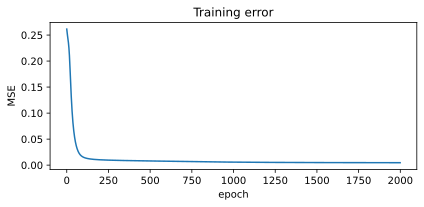

In [10]:
plt.figure(figsize=(6, 3))
plt.plot(risks)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Training error")
plt.tight_layout()

## Step 5) Make Predictions

Now we have a trained model. We can use it to make predictions by feeding a tensor into `model()`. Remember, we trained our network on *standardized* data. This means we need to evaluate it on standardized data, too. We use the same `mu` and `sigma` that we calculated on the training set:

In [11]:
X_test = [
    [10, 80], # i.e., 10am, 80 degrees
    [9, 50],
    [12, 70]
]

# standardize
X_test = torch.tensor(
    (X_test - mu)/sigma,
    # we trained our network using floats, so we need to use the same data type
    # at test time.
    dtype=torch.float
)

In [12]:
predictions = model(X_test)
predictions

tensor([[6.6261e-05],
        [1.0000e+00],
        [9.5069e-04]], grad_fn=<SigmoidBackward0>)

Note that the labels we used in training were 0 and 1. The output of our network is a number between 0 and 1 (since we used the sigmoid), and to turn it into a binary classification prediction we should compare it to the natural threshold of 1/2.

In [13]:
predictions > 0.5

tensor([[False],
        [ True],
        [False]])

## Decision Boundary

Let's see what our NN's decision boundary looks like. The function below evaluates the NN at a bunch of places and finds where the output is exactly 1/2 (when our labels are not -1 and 1 but instead 0 and 1, the decision boundary is where H = 1/2).

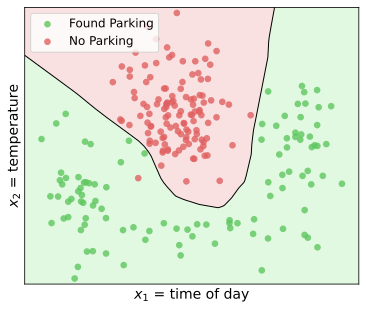

In [14]:
util.plot_decision_boundary(model, time, temp, label, mu, sigma);

## Learned Feature Map

The hidden layers before the final linear classifier form a learned feature map $\varphi: \mathbb{R}^2 \to \mathbb{R}^2$. Because we placed a 2-dimensional bottleneck before the output layer, we can visualize exactly what the network learned. If our last hidden layer had, say, 8 nodes instead of 2, the network would still be learning a feature map, it just wouldn't be one that we humans can visualize.

The last layer is just a linear classifier (plus sigmoid) in this 2D feature space — so if the hidden layers did their job, the two classes should be **linearly separable** after the transformation. Let's take a look.

We can "slice" the network using Python slice notation. The below gives us a new network by removing the output layer. Although our network has 5 layers (input, hidden, hidden, hidden, output), PyTorch counts the activation as a separate layer, and the input layer isn't counted. So, according to PyTorch, the layers of the network look like: (hidden 1 linear, hidden 1 ReLU, hidden 2 linear, hidden 2 ReLu, hidden 3 linear, hidden 3 Relu, output linear, output sigmoid). If we take the first 6 of these, we effectively slice off the output layer:

In [15]:
# The feature map is everything before the final ReLU + Linear + Sigmoid
feature_map = model[:6]

In [16]:
X_phi = feature_map(X_train).detach().numpy()

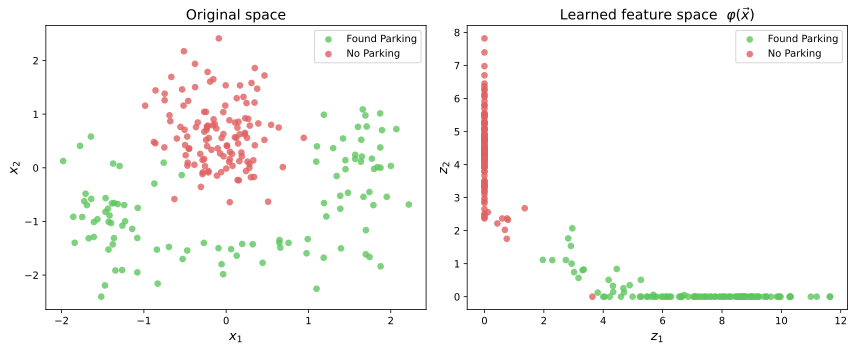

In [17]:
util.plot_feature_map(X_std, X_phi, label);

You should see that the data is now effectively linearly-separable in "feature space". This is the data that the very last layer of the network -- the output layer -- sees. It's job is to classify this data, and it has a much easier job than classifying the original data.

In effect, the neural network *learned* a good feature map. We didn't explicitly tell it to learn a good feature map -- we told it to minimize prediction error. In a sense, the network has found a good feature map as a byproduct of learning to classify, and the feature map it has found is optimized for making good predictions.

## Training with Mini-Batch SGD

The training loop above passes the *entire* dataset through the model at every epoch. That is, it used a batch size equal to $n$. Therefore, despite using `torch.optim.SGD`, we were actually using plain (batch) gradient descent.

In true stochastic gradient descent, we update the weights using a small *mini-batch* of training examples at each step. PyTorch's `DataLoader` handles splitting the data into mini-batches and shuffling them each epoch. The `batch_size` parameter explicitly controls how many examples are in each mini-batch.

In [18]:
from torch.utils.data import DataLoader, TensorDataset

# set the seed so that we get the same results every time
torch.manual_seed(42)

# wrap the training data in a DataLoader; batch_size controls the mini-batch size
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# same architecture as before, freshly initialized
model_sgd = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid(),
)

optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.5)

In [19]:
risks_sgd = []

for epoch in range(200):
    epoch_loss = 0.0

    # the key difference: instead of using all of X_train at once,
    # we iterate over mini-batches provided by the DataLoader
    for X_batch, y_batch in loader:
        predictions = model_sgd(X_batch)
        loss = loss_fn(predictions, y_batch)

        optimizer_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()

        epoch_loss += loss.item() * len(X_batch)

    epoch_loss /= len(dataset)
    risks_sgd.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:4d}  loss = {epoch_loss:.4f}")

epoch  100  loss = 0.0067
epoch  200  loss = 0.0049


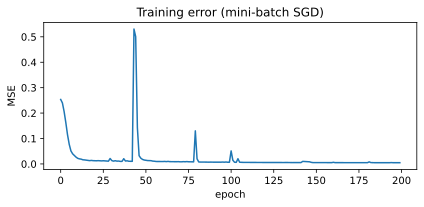

In [20]:
plt.figure(figsize=(6, 3))
plt.plot(risks_sgd)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Training error (mini-batch SGD)")
plt.tight_layout()

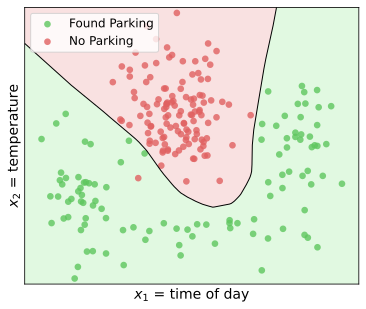

In [21]:
util.plot_decision_boundary(model_sgd, time, temp, label, mu, sigma);

Notice that the loss curve is noisier than the one produced by full-batch gradient descent. This is expected: each mini-batch gives a *noisy estimate* of the true gradient, so the loss jumps around from epoch to epoch. Despite the noise, mini-batch SGD often converges faster in wall-clock time on large datasets because each weight update is much cheaper to compute.

## Things to try

Here are some things you should try:

- Change the learning rate. What happens if you make it too big? Too small?
- Change the network architecture. Start by reducing the number of nodes in each layer (leave the last hidden layer at 2 if you still want to visualize the feature map). Then try increasing the number of nodes.
- Try changing the ReLU to sigmoid.
- Try to make the network overfit. Then reduce the number of training epochs. You might see that the over-fitting was reduced; this is called "early stopping".